## Dependencies

In [ ]:
import numpy as np
import nibabel as nib
import torch.nn.functional as F
import glob
import matplotlib.pyplot as plt
from tifffile import imwrite
from sklearn.preprocessing import MinMaxScaler
import torch
from pathlib import Path
import os
import splitfolders
import shutil
from torch.utils.data import Dataset,DataLoader

scaler=MinMaxScaler()
TRAIN_DATASET_PATH = Path('../data/brats20/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/')
VALIDATION_DATASET_PATH = Path('../data/brats20/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData')
file_number = np.random.randint(100,369)

## EDA

1854.603271484375
[0 1 2 4]
[0 1 2 3]
(240, 240, 155)
Slice number: 141


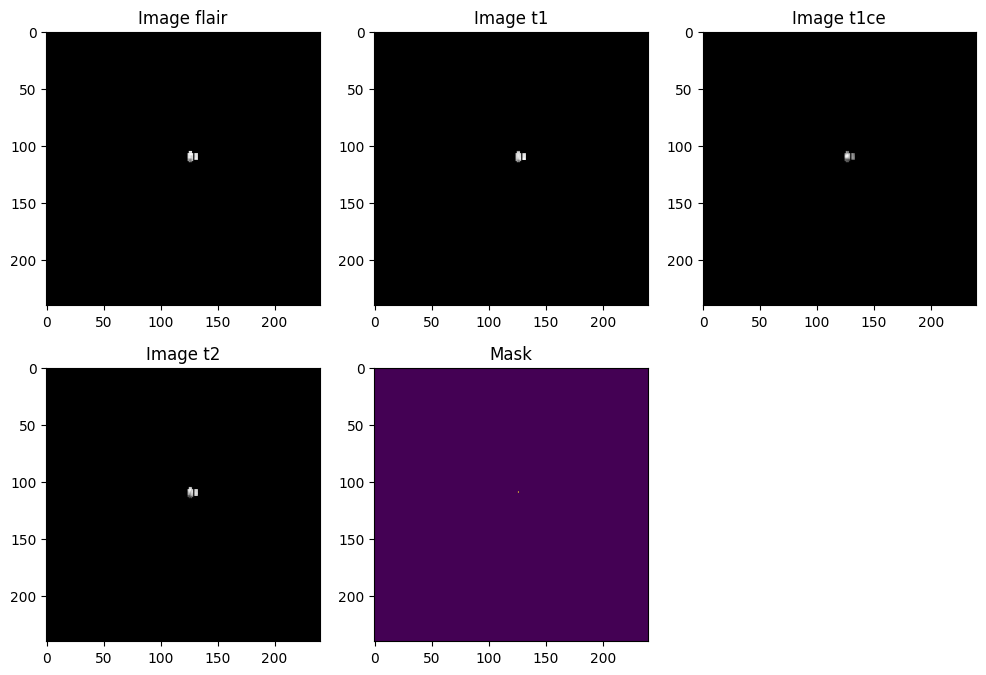

(240, 240, 155)


In [ ]:
test_image_flair=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_flair.nii'))).get_fdata()
print(test_image_flair.max())
#Scalers are applied to 1D so let us reshape and then reshape back to original shape. 
test_image_flair=scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)


test_image_t1=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t1.nii'))).get_fdata()
test_image_t1=scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

test_image_t1ce=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t1ce.nii'))).get_fdata()
test_image_t1ce=scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

test_image_t2=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t2.nii'))).get_fdata()
test_image_t2=scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

test_mask=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_seg.nii'))).get_fdata()
test_mask=test_mask.astype(np.uint8)

print(np.unique(test_mask))  #0, 1, 2, 4 (Need to reencode to 0, 1, 2, 3)
test_mask[test_mask==4] = 3  #Reassign mask values 4 to 3
print(np.unique(test_mask)) 

print(test_image_flair.shape)

import random
n_slice=random.randint(0, test_mask.shape[2]-1)
print('Slice number:',n_slice)

plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(test_image_flair[:,:,n_slice], cmap='gray')
plt.title('Image flair')
plt.subplot(232)
plt.imshow(test_image_t1[:,:,n_slice], cmap='gray')
plt.title('Image t1')
plt.subplot(233)
plt.imshow(test_image_t1ce[:,:,n_slice], cmap='gray')
plt.title('Image t1ce')
plt.subplot(234)
plt.imshow(test_image_t2[:,:,n_slice], cmap='gray')
plt.title('Image t2')
plt.subplot(235)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

print(test_mask.shape)

Original shape of input: (240, 240, 155, 3)
FInal shape of input: (144, 144, 128, 3)
Final shape of mask: (144, 144, 128)
Slice number: 59


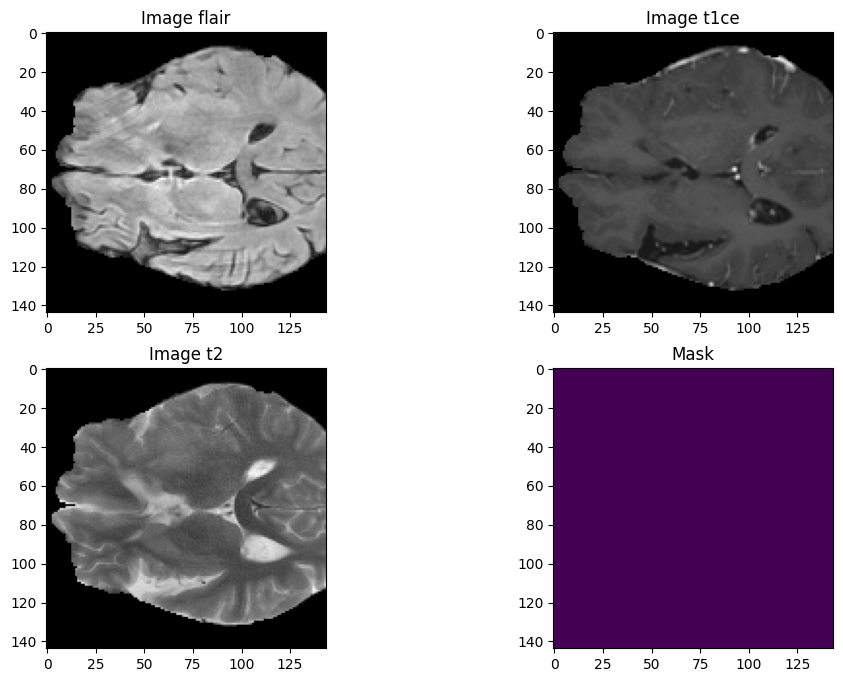

Encoded mask: torch.Size([144, 144, 128, 4])


In [ ]:
combined_x = np.stack([test_image_flair, test_image_t1ce, test_image_t2], axis=3)
print("Original shape of input:",combined_x.shape)

#Crop to a size to be divisible by 64 so we can later extract 64x64x64 patches. 
#cropping x, y, and z
#combined_x=combined_x[24:216, 24:216, 13:141]

combined_x=combined_x[48:192,48:192,13:141] #Crop to 128x128x128x4
print("FInal shape of input:",combined_x.shape)

#Do the same for mask
test_mask_2 = test_mask[48:192,48:192,13:141]

print("Final shape of mask:",test_mask_2.shape)


n_slice=random.randint(0, test_mask_2.shape[2]-1)
print("Slice number:",n_slice)
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(combined_x[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(combined_x[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(combined_x[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask_2[:,:,n_slice])
plt.title('Mask')
plt.show()

test_mask_2 = F.one_hot(torch.tensor(test_mask_2).long(), num_classes=4)
print("Encoded mask:",test_mask_2.shape)

# Data Pipeline

## Data Transform 1

### Helper function

In [ ]:
def transform_nii_to_np(t2_list:list,t1ce_list:list,flair_list:list,mask_list:list,save_images:str,save_masks:str):

    os.makedirs(save_images,exist_ok=True)
    os.makedirs(save_masks,exist_ok=True)
    saved_samples = []
    discarded_samples = []
    
    for img in range(len(t2_list)):
        img_t2 = nib.load(filename=t2_list[img]).get_fdata()
        img_t2 = scaler.fit_transform(img_t2.reshape(-1,img_t2.shape[-1])).reshape(img_t2.shape)

        img_t1ce = nib.load(filename=t1ce_list[img]).get_fdata()
        img_t1ce = scaler.fit_transform(img_t1ce.reshape(-1,img_t1ce.shape[-1])).reshape(img_t1ce.shape)

        img_flair = nib.load(filename=flair_list[img]).get_fdata()
        img_flair = scaler.fit_transform(img_flair.reshape(-1,img_flair.shape[-1])).reshape(img_flair.shape)

        stacked_img = np.stack([img_flair,img_t1ce,img_t2],axis=3)
        stacked_img = stacked_img[48:192,48:192,13:141]

        img_mask = nib.load(filename=mask_list[img]).get_fdata().astype(np.uint8)
        img_mask[img_mask==4]=3
        img_mask = img_mask[48:192,48:92,13:141]

        val,counts = np.unique(img_mask,return_counts=True)

        if (1-(counts[0]/counts.sum())) > 0.01:
            saved_samples.append(img)
            img_mask_np = F.one_hot(torch.tensor(img_mask).long(),num_classes=4).numpy()
            np.save(file=f"../data/brats20/train_data_3channel/images/image_{img}.npy",arr=stacked_img)
            np.save(file=f"../data/brats20/train_data_3channel/masks/mask_{img}.npy",arr=img_mask_np)
        else:
            discarded_samples.append(img)

    return saved_samples,discarded_samples

### Training data

In [ ]:
t2_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*t2.nii'))
t1ce_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*t1ce.nii'))
flair_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*flair.nii'))
mask_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*seg.nii'))
save_images = "../data/brats20/train_data_3channel/images/"
save_masks = "../data/brats20/train_data_3channel/masks/"

saved,discarded = transform_nii_to_np(t1ce_list=t1ce_list,
                    t2_list=t2_list,
                    flair_list=flair_list,
                    mask_list=mask_list,
                    save_images=save_images,
                    save_masks=save_masks)

print(f'Saved files: {len(saved)}\n\n {saved}\n\nDiscarded files: {len(discarded)} \n\n {discarded}')

KeyboardInterrupt: 

In [ ]:
io_folder = "../data/brats20/train_data_3channel/"
splitfolders.ratio(input=io_folder,output = io_folder, seed = 42, ratio=(.75,.25),group_prefix = None)
shutil.rmtree(save_images)
shutil.rmtree(save_masks)

### Test data

In [ ]:
# t2_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*t2.nii'))
# t1ce_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*t1ce.nii'))
# flair_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*flair.nii'))
# mask_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*seg.nii'))
# save_images = "../data/brats20/test_data_3channel/images/"
# save_masks = "../data/brats20/test_data_3channel/masks/"

# saved,discarded = transform_nii_to_np(t1ce_list=t1ce_list,
#                     t2_list=t2_list,
#                     flair_list=flair_list,
#                     mask_list=mask_list,
#                     save_images=save_images,
#                     save_masks=save_masks)

# print(f'Saved files: {len(saved)}\n\n {saved}\n\nDiscarded files: {len(discarded)} \n\n {discarded}')

In [ ]:
# io_folder = "../data/brats20/test_data_3channel/"
# shutil.rmtree(save_images)
# shutil.rmtree(save_masks)

## Creating Data loaders

In [ ]:
class BraTsDataset(Dataset):
    def __init__(self, img_dir:str, img_list:list, mask_dir:str, mask_list:list):
        self.img_dir = img_dir
        self.img_list = img_list
        self.mask_dir = mask_dir
        self.mask_list = mask_list

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img = torch.from_numpy(np.load(self.img_dir + self.img_list[idx])).float()
        mask = torch.from_numpy(np.load(self.mask_dir + self.mask_list[idx])).long()
        return img, mask
    

In [ ]:
img_dir = "../data/brats20/train_data_3channel/train/images/"
masks_dir = "../data/brats20/train_data_3channel/train/masks/"
img_list = os.listdir(path=img_dir)
mask_list = os.listdir(path=masks_dir)


train_data = BraTsDataset(img_dir=img_dir,
                          img_list=img_list,
                          mask_dir=masks_dir,
                          mask_list=mask_list)
train_loader = DataLoader(train_data,batch_size=8,shuffle=True)

['image_0.npy', 'image_1.npy', 'image_10.npy', 'image_101.npy', 'image_102.npy', 'image_103.npy', 'image_104.npy', 'image_105.npy', 'image_106.npy', 'image_108.npy', 'image_11.npy', 'image_112.npy', 'image_115.npy', 'image_116.npy', 'image_117.npy', 'image_118.npy', 'image_119.npy', 'image_122.npy', 'image_123.npy', 'image_124.npy', 'image_125.npy', 'image_127.npy', 'image_128.npy', 'image_129.npy', 'image_13.npy', 'image_131.npy', 'image_134.npy', 'image_135.npy', 'image_136.npy', 'image_139.npy', 'image_14.npy', 'image_140.npy', 'image_143.npy', 'image_144.npy', 'image_146.npy', 'image_148.npy', 'image_150.npy', 'image_151.npy', 'image_152.npy', 'image_153.npy', 'image_155.npy', 'image_156.npy', 'image_157.npy', 'image_158.npy', 'image_159.npy', 'image_160.npy', 'image_161.npy', 'image_162.npy', 'image_163.npy', 'image_164.npy', 'image_165.npy', 'image_166.npy', 'image_168.npy', 'image_169.npy', 'image_17.npy', 'image_170.npy', 'image_171.npy', 'image_172.npy', 'image_173.npy', 'imag

Slice number: 80


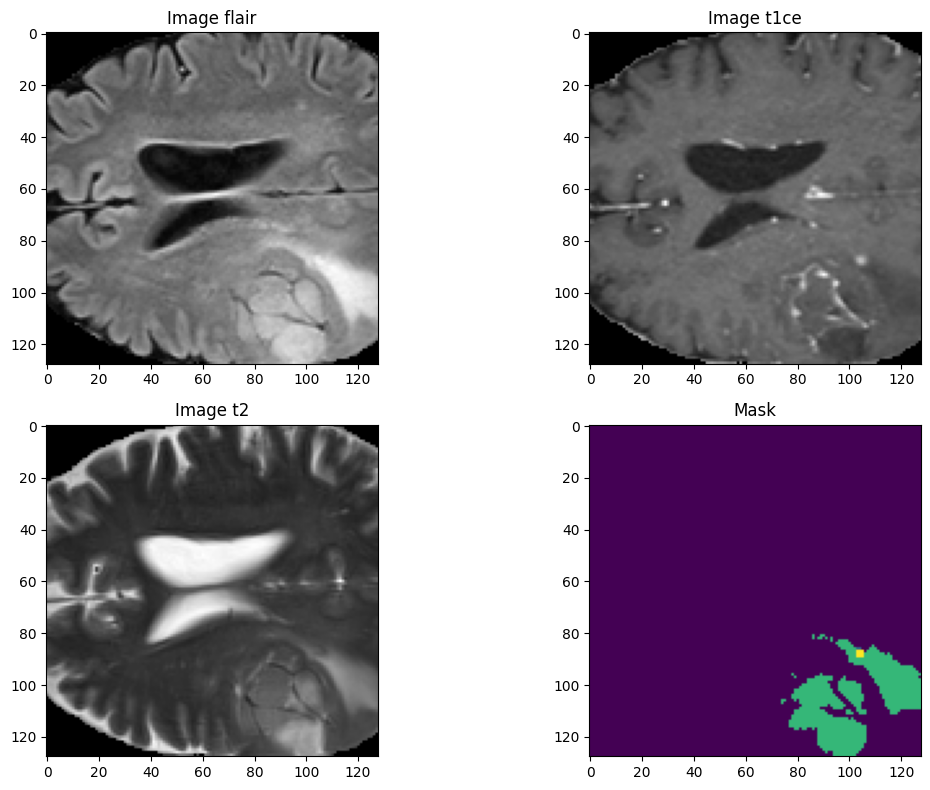

In [ ]:
# Assume: img, msk are torch tensors from a DataLoader
img, msk = next(iter(train_loader))  # one batch

img_num = np.random.randint(0, img.shape[0] - 1)
test_img = img[img_num].detach().cpu().numpy()
test_mask = msk[img_num].detach().cpu().numpy()

# If your mask has one-hot encoding or channel dim
if test_mask.ndim == 4:  # (C, H, W, D) or (B, C, H, W)
    test_mask = np.argmax(test_mask, axis=3)

n_slice = np.random.randint(0, test_mask.shape[2])
print('Slice number:',n_slice)
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:, :, n_slice, 0], cmap='gray')
plt.title('Image flair')

plt.subplot(222)
plt.imshow(test_img[:, :, n_slice, 1], cmap='gray')
plt.title('Image t1ce')

plt.subplot(223)
plt.imshow(test_img[:, :, n_slice, 2], cmap='gray')
plt.title('Image t2')

plt.subplot(224)
plt.imshow(test_mask[:, :, n_slice])
plt.title('Mask')

plt.tight_layout()
plt.show()
